In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import LabelEncoder

In [37]:
secondary = pd.read_csv('data\\secondary_centroids\\AF-Q59939-F1-model_v6_centroids.csv')

In [39]:
secondary

,id,conf_type_id,beg_chain,beg_seq,beg_res,end_chain,end_seq,end_res,n_atoms,mean_x,mean_y,mean_z
0,HELX_LH_PP_P1,HELX_LH_PP_P,A,2,ALA,A,4,THR,21,0.595,32.483,4.416
1,TURN_TY1_P1,TURN_TY1_P,A,6,GLY,A,9,ASP,29,-2.237,23.221,-0.789
2,BEND1,BEND,A,16,ARG,A,17,ILE,19,-1.863,7.770,-15.426
3,STRN1,STRN,A,18,SER,A,21,LYS,28,-10.135,11.846,-8.677
4,TURN_TY1_P2,TURN_TY1_P,A,22,ASP,A,23,ASN,16,-17.044,13.410,-5.180
...,...,...,...,...,...,...,...,...,...,...,...,...
61,HELX_LH_PP_P8,HELX_LH_PP_P,A,354,PRO,A,356,SER,24,12.075,27.809,-4.488
62,BEND13,BEND,A,360,GLY,A,360,GLY,4,14.428,36.145,7.088
63,BEND14,BEND,A,363,LYS,A,363,LYS,9,20.644,43.874,5.294
64,HELX_LH_PP_P9,HELX_LH_PP_P,A,364,LEU,A,368,PRO,46,28.549,40.200,11.822


In [40]:
distances = euclidean_distances(secondary[['mean_x', 'mean_y', 'mean_z']])

In [49]:
encoded_conf_type = LabelEncoder().fit_transform(secondary.conf_type_id)

In [50]:
c1 = np.repeat(np.array(encoded_conf_type)[:, np.newaxis], repeats=len(encoded_conf_type), axis=1)

In [51]:
secondary.conf_type_id

0     HELX_LH_PP_P
1       TURN_TY1_P
2             BEND
3             STRN
4       TURN_TY1_P
          ...     
61    HELX_LH_PP_P
62            BEND
63            BEND
64    HELX_LH_PP_P
65    HELX_RH_3T_P
Name: conf_type_id, Length: 66, dtype: str

In [52]:
c2 = c1.T

In [53]:
c2

array([[1, 5, 0, ..., 0, 1, 2],
       [1, 5, 0, ..., 0, 1, 2],
       [1, 5, 0, ..., 0, 1, 2],
       ...,
       [1, 5, 0, ..., 0, 1, 2],
       [1, 5, 0, ..., 0, 1, 2],
       [1, 5, 0, ..., 0, 1, 2]], shape=(66, 66))

In [68]:
dist_and_type = np.stack([distances/np.max(distances), c1/np.max(c1), c2/np.max(c2)])

In [69]:
from matplotlib import pyplot as plt

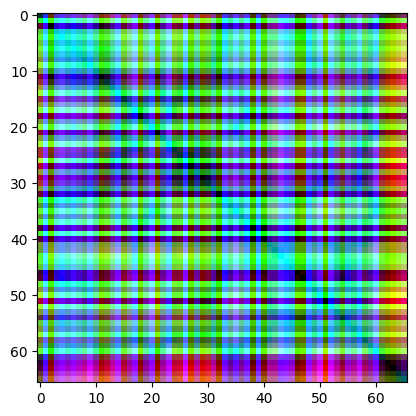

In [70]:
plt.imshow(np.transpose(dist_and_type, (1, 2, 0)))